In [79]:
import pandas as pd

In [80]:
weather_data = pd.read_csv('data/fullweather.csv',parse_dates=['time'],encoding='utf-8')
print(weather_data.head())

        time  temperature_2m_mean (°C)  daylight_duration (s)  rain_sum (mm)  \
0 2023-01-01                      17.9               37640.81            0.0   
1 2023-01-02                      18.8               37666.55            0.0   
2 2023-01-03                      19.3               37694.59            0.0   
3 2023-01-04                      19.7               37724.89            0.0   
4 2023-01-05                      20.2               37757.38            0.7   

   snowfall_sum (cm)  relative_humidity_2m_mean (%)  pressure_msl_mean (hPa)  \
0                0.0                             43                   1022.7   
1                0.0                             29                   1024.5   
2                0.0                             21                   1025.2   
3                0.0                             15                   1022.4   
4                0.0                             52                   1020.6   

   surface_pressure_mean (hPa)  temper

In [81]:
print(weather_data.dtypes)

time                               datetime64[us]
temperature_2m_mean (°C)                  float64
daylight_duration (s)                     float64
rain_sum (mm)                             float64
snowfall_sum (cm)                         float64
relative_humidity_2m_mean (%)               int64
pressure_msl_mean (hPa)                   float64
surface_pressure_mean (hPa)               float64
temperature_2m_max (°C)                   float64
temperature_2m_min (°C)                   float64
cloud_cover_mean (%)                        int64
wind_speed_10m_max (km/h)                 float64
precipitation_sum (mm)                    float64
sunshine_duration (s)                     float64
wind_direction_10m_dominant (°)             int64
longitude                                 float64
latitude                                  float64
elevation                                 float64
dtype: object


In [82]:
print(weather_data.shape)

(5440, 18)


In [83]:
corr_matrix = weather_data.corr(numeric_only=True)
print(corr_matrix)

                                 temperature_2m_mean (°C)  \
temperature_2m_mean (°C)                         1.000000   
daylight_duration (s)                            0.693607   
rain_sum (mm)                                   -0.143742   
snowfall_sum (cm)                               -0.204060   
relative_humidity_2m_mean (%)                   -0.440276   
pressure_msl_mean (hPa)                         -0.853584   
surface_pressure_mean (hPa)                      0.222469   
temperature_2m_max (°C)                          0.982482   
temperature_2m_min (°C)                          0.977457   
cloud_cover_mean (%)                            -0.410284   
wind_speed_10m_max (km/h)                        0.400809   
precipitation_sum (mm)                          -0.184151   
sunshine_duration (s)                            0.535884   
wind_direction_10m_dominant (°)                 -0.171308   
longitude                                        0.189965   
latitude                

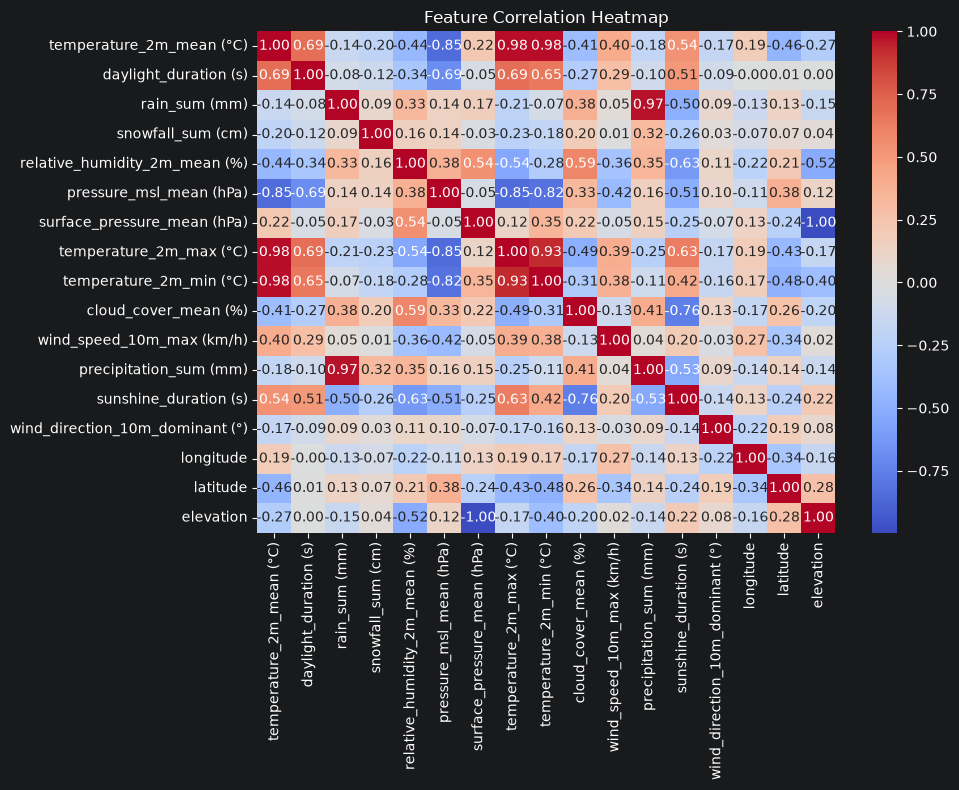

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [85]:
print(corr_matrix['temperature_2m_mean (°C)'])

temperature_2m_mean (°C)           1.000000
daylight_duration (s)              0.693607
rain_sum (mm)                     -0.143742
snowfall_sum (cm)                 -0.204060
relative_humidity_2m_mean (%)     -0.440276
pressure_msl_mean (hPa)           -0.853584
surface_pressure_mean (hPa)        0.222469
temperature_2m_max (°C)            0.982482
temperature_2m_min (°C)            0.977457
cloud_cover_mean (%)              -0.410284
wind_speed_10m_max (km/h)          0.400809
precipitation_sum (mm)            -0.184151
sunshine_duration (s)              0.535884
wind_direction_10m_dominant (°)   -0.171308
longitude                          0.189965
latitude                          -0.461940
elevation                         -0.273076
Name: temperature_2m_mean (°C), dtype: float64


In [86]:
feature_cols = [c for c in weather_data.columns if c != "temperature_2m_mean (°C)" and c not in ["time"]]
feature_corr = weather_data[feature_cols].corr()

In [87]:
pairs = []
for i in range(len(feature_corr.columns)):
    for j in range(i+1, len(feature_corr.columns)):
        col1, col2 = feature_corr.columns[i], feature_corr.columns[j]
        val = feature_corr.iloc[i, j]
        if abs(val) > 0.8:
            pairs.append((col1, col2, round(val, 3)))

pairs_weather_data = pd.DataFrame(pairs, columns=["feature_1", "feature_2", "correlation"])
print(pairs_weather_data.sort_values("correlation", ascending=False))

                     feature_1                feature_2  correlation
0                rain_sum (mm)   precipitation_sum (mm)        0.973
4      temperature_2m_max (°C)  temperature_2m_min (°C)        0.928
2      pressure_msl_mean (hPa)  temperature_2m_min (°C)       -0.823
1      pressure_msl_mean (hPa)  temperature_2m_max (°C)       -0.849
3  surface_pressure_mean (hPa)                elevation       -0.996


In [88]:
weather_data["temp_range"] = weather_data["temperature_2m_max (°C)"] - weather_data["temperature_2m_min (°C)"]
weather_data["sunshine_ratio"] = weather_data["sunshine_duration (s)"] / weather_data["daylight_duration (s)"]

In [89]:
new_features = ["temp_range", "sunshine_ratio","temperature_2m_mean (°C)"]
print(weather_data[new_features].corr())

                          temp_range  sunshine_ratio  temperature_2m_mean (°C)
temp_range                  1.000000        0.627667                  0.160301
sunshine_ratio              0.627667        1.000000                  0.312551
temperature_2m_mean (°C)    0.160301        0.312551                  1.000000


In [90]:
# Sort by location and time first
weather_data = weather_data.sort_values(["latitude", "longitude", "time"]).reset_index(drop=True)
group_cols = ["latitude", "longitude"]  # identifies each city

# Create the target: tomorrow's mean temp
weather_data["target_temp_next_day"] = weather_data.groupby(group_cols)["temperature_2m_mean (°C)"].shift(-1)

# Drop rows where target is NaN (last day per city, no "tomorrow" available)
weather_data = weather_data.dropna(subset=["target_temp_next_day"])

print(weather_data[["time", "temperature_2m_mean (°C)", "target_temp_next_day"]].head(10))
print(group_cols)

        time  temperature_2m_mean (°C)  target_temp_next_day
0 2023-01-01                      17.9                  18.8
1 2023-01-02                      18.8                  19.3
2 2023-01-03                      19.3                  19.7
3 2023-01-04                      19.7                  20.2
4 2023-01-05                      20.2                  18.0
5 2023-01-06                      18.0                  16.0
6 2023-01-07                      16.0                  15.7
7 2023-01-08                      15.7                  16.3
8 2023-01-09                      16.3                  17.9
9 2023-01-10                      17.9                  15.5
['latitude', 'longitude']


In [92]:
weather_data["month"] = weather_data["time"].dt.month
weather_data["day_of_year"] = weather_data["time"].dt.dayofyear
weather_data["day_of_week"] = weather_data["time"].dt.dayofweek

# month 12 and month 1 are "close" but 12 ≠ 1 numerically
import numpy as np
weather_data["day_of_year_sin"] = np.sin(2 * np.pi * weather_data["day_of_year"] / 365)
weather_data["day_of_year_cos"] = np.cos(2 * np.pi * weather_data["day_of_year"] / 365)

weather_data = weather_data.drop(columns=["day_of_year"])

In [93]:
import numpy as np
weather_data["wind_dir_sin"] = np.sin(np.deg2rad(weather_data["wind_direction_10m_dominant (°)"]))
weather_data["wind_dir_cos"] = np.cos(np.deg2rad(weather_data["wind_direction_10m_dominant (°)"]))

print(weather_data.columns.tolist())

['time', 'temperature_2m_mean (°C)', 'daylight_duration (s)', 'rain_sum (mm)', 'snowfall_sum (cm)', 'relative_humidity_2m_mean (%)', 'pressure_msl_mean (hPa)', 'surface_pressure_mean (hPa)', 'temperature_2m_max (°C)', 'temperature_2m_min (°C)', 'cloud_cover_mean (%)', 'wind_speed_10m_max (km/h)', 'precipitation_sum (mm)', 'sunshine_duration (s)', 'wind_direction_10m_dominant (°)', 'longitude', 'latitude', 'elevation', 'temp_range', 'sunshine_ratio', 'target_temp_next_day', 'month', 'day_of_week', 'day_of_year_sin', 'day_of_year_cos', 'wind_dir_sin', 'wind_dir_cos']


In [ ]:
# dropping unnecessary features
weather_data = weather_data.drop(columns=[
    'rain_sum (mm)',
    'surface_pressure_mean (hPa)',
    'wind_direction_10m_dominant (°)',
])

In [100]:
# Use last ~20% of dates as test set, per city
split_date = weather_data["time"].quantile(0.8)

train = weather_data[weather_data["time"] < split_date]
test = weather_data[weather_data["time"] >= split_date]

print(f"Train: {train.shape}, Test: {test.shape}")
print(f"Train date range: {train['time'].min()} to {train['time'].max()}")
print(f"Test date range: {test['time'].min()} to {test['time'].max()}")

Train: (4345, 24), Test: (1090, 24)
Train date range: 2023-01-01 00:00:00 to 2025-05-18 00:00:00
Test date range: 2025-05-19 00:00:00 to 2025-12-22 00:00:00


In [101]:
from sklearn.preprocessing import StandardScaler

feature_cols = [c for c in train.columns if c not in ["time", "target_temp_next_day"]]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train[feature_cols])
X_test_scaled = scaler.transform(test[feature_cols])

In [102]:
train.to_csv("data/train_processed.csv", index=False)
test.to_csv("data/test_processed.csv", index=False)